In [1]:
import numpy as np
from numpy.linalg import norm
import pywt

from importlib import reload
import matplotlib.pyplot as plt

import pytempscsp.tempscsp as tempscsp
import pytempscsp.tempscsel as tempscsel
import pytempscsp.bandpass as bandpass

In [2]:
reload(bandpass)

<module 'pytempscsp.bandpass' from '/Users/tony/Work/GitHub.com-mirror/pytempscsp/pytempscsp/bandpass.py'>

In [3]:
# The test signal 'Blocks', originally due to Donoho, generated by the function pywt.data.demo_signal() in the PyWavelets library for n = 30.
blocks = pywt.data.demo_signal(name='Blocks', n=30)

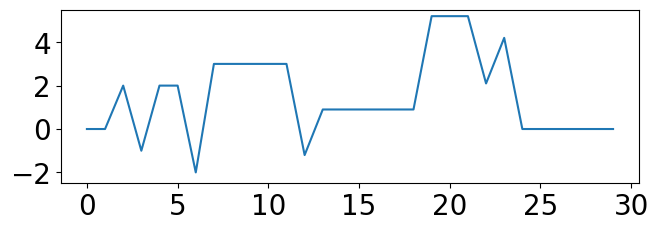

In [4]:
plt.plot(blocks)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 5.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout(pad=0, w_pad=0, h_pad=0)
plt.savefig('figs/blocks.pdf', transparent=True)
plt.savefig('figs/blocks.eps', transparent=True)

In [5]:
(blockssmooth, scales) = tempscsp.limitkernfilt_mult(blocks, 1, 8, 2, 4)
blockssmooth.shape[0]

4

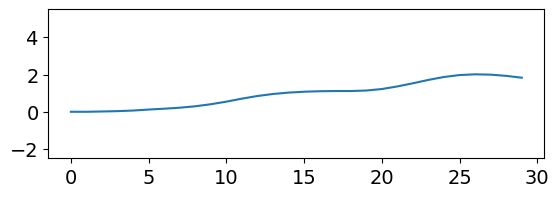

In [6]:
plt.plot(blockssmooth[3])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.gca().set_ylim([-2.5, 5.5])
plt.gca().axes.set_box_aspect(0.3)

In [7]:
DoT, lastlevel = bandpass.bandpass_DoT(blocks, 1, 8, 2, 4)

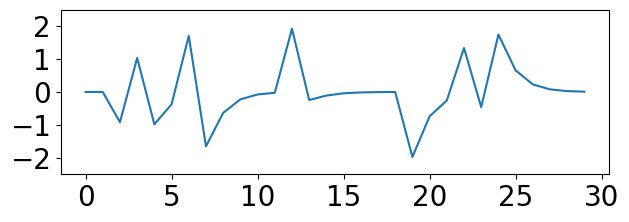

In [8]:
plt.plot(DoT[0])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoT-band0.pdf', transparent=True)
plt.savefig('figs/blocks-DoT-band0.eps', transparent=True)

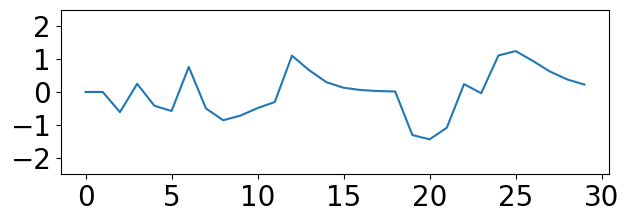

In [9]:
plt.plot(DoT[1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoT-band1.pdf', transparent=True)
plt.savefig('figs/blocks-DoT-band1.eps', transparent=True)

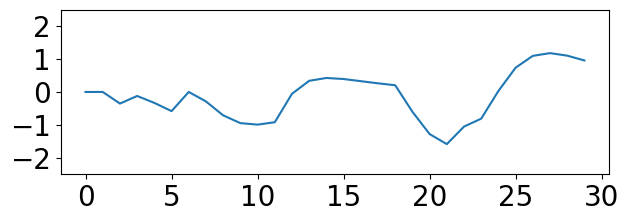

In [10]:
plt.plot(DoT[2])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoT-band2.pdf', transparent=True)
plt.savefig('figs/blocks-DoT-band2.eps', transparent=True)

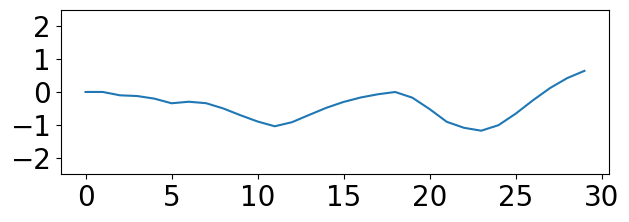

In [11]:
plt.plot(DoT[3])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoT-band3.pdf', transparent=True)
plt.savefig('figs/blocks-DoT-band3.eps', transparent=True)

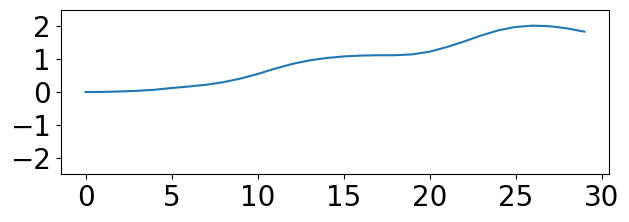

In [12]:
plt.plot(lastlevel)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoT-last.pdf', transparent=True)
plt.savefig('figs/blocks-DoT-last.eps', transparent=True)

In [13]:
reconstr_DoT = bandpass.reconstr_from_bandpass_DoT(DoT, lastlevel)
reconstr_DoT.shape

(30,)

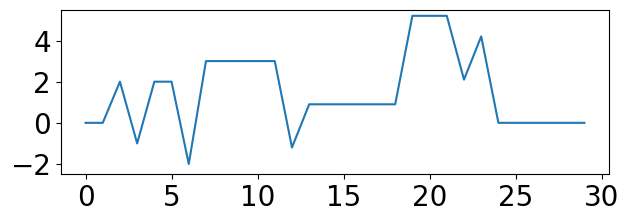

In [14]:
plt.plot(reconstr_DoT)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 5.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoT-reconstr.pdf', transparent=True)
plt.savefig('figs/blocks-DoT-reconstr.eps', transparent=True)

In [15]:
blocks - reconstr_DoT

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.11022302e-16,
        0.00000000e+00,  0.00000000e+00, -4.44089210e-16, -4.44089210e-16,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -1.11022302e-16, -1.11022302e-16,  0.00000000e+00,
        0.00000000e+00,  1.11022302e-16, -2.22044605e-16,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -2.22044605e-16,  0.00000000e+00,  0.00000000e+00,
       -2.22044605e-16, -1.11022302e-16])

In [16]:
norm(blocks - reconstr_DoT)/norm(blocks)

np.float64(5.934910798332411e-17)

In [17]:
norm(blocks)

np.float64(13.09465539829132)

In [18]:
bandpass.distr_sc_levels(1, 9.1, 2)

array([1., 2., 4., 8.])

In [19]:
DoG, lastlevel = bandpass.bandpass_DoG(blocks, 1, 8.1, 2)

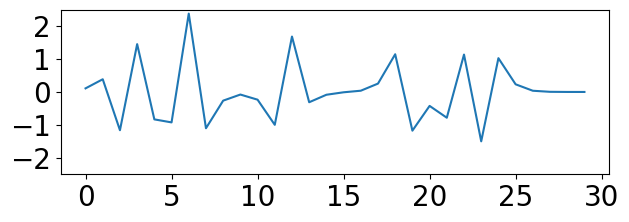

In [20]:
plt.plot(DoG[0])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoG-band0.pdf', transparent=True)
plt.savefig('figs/blocks-DoG-band0.eps', transparent=True)

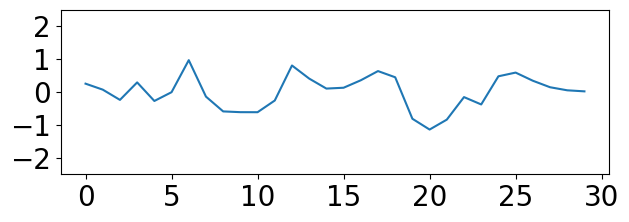

In [21]:
plt.plot(DoG[1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoG-band1.pdf', transparent=True)
plt.savefig('figs/blocks-DoG-band1.eps', transparent=True)

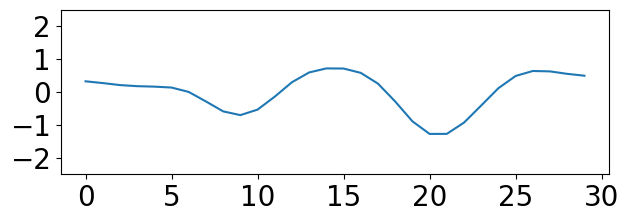

In [22]:
plt.plot(DoG[2])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoG-band2.pdf', transparent=True)
plt.savefig('figs/blocks-DoG-band2.eps', transparent=True)

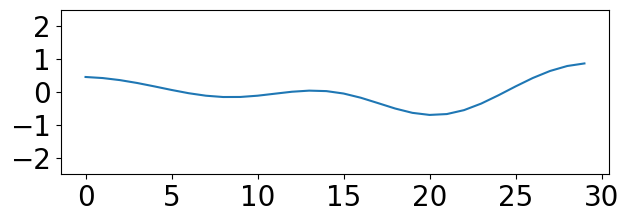

In [23]:
plt.plot(DoG[3])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoG-band3.pdf', transparent=True)
plt.savefig('figs/blocks-DoG-band3.eps', transparent=True)

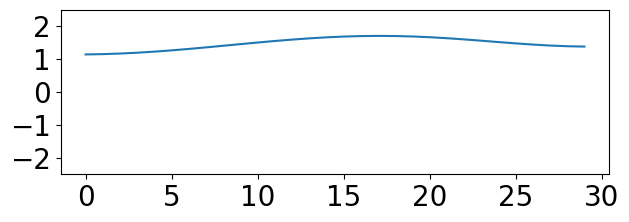

In [24]:
plt.plot(lastlevel)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoG-last.pdf', transparent=True)
plt.savefig('figs/blocks-DoG-last.eps', transparent=True)

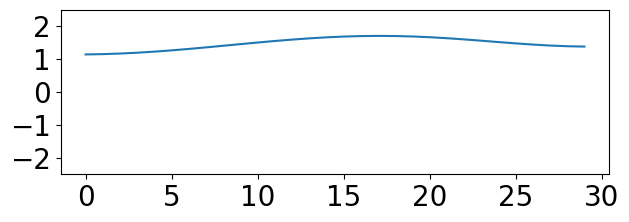

In [25]:
plt.plot(lastlevel)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoG-last.pdf', transparent=True)
plt.savefig('figs/blocks-DoG-last.eps', transparent=True)

In [26]:
reconstr_DoG = bandpass.reconstr_from_bandpass_DoG(DoG, lastlevel)
reconstr_DoG.shape

(30,)

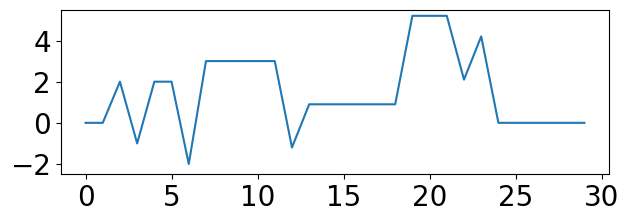

In [27]:
plt.plot(reconstr_DoG)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 5.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoG-reconstr.pdf', transparent=True)
plt.savefig('figs/blocks-DoG-reconstr.eps', transparent=True)

In [28]:
blocks - reconstr_DoG

array([-1.11022302e-16,  0.00000000e+00,  0.00000000e+00, -1.11022302e-16,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        4.44089210e-16,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -1.11022302e-16,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00])

In [29]:
norm(blocks - reconstr_DoG)/norm(blocks)

np.float64(3.6956680584084694e-17)

In [30]:
norm(blocks)

np.float64(13.09465539829132)

In [31]:
DoE, lastlevel = bandpass.bandpass_DoE(blocks, 1, 8.1, 2)

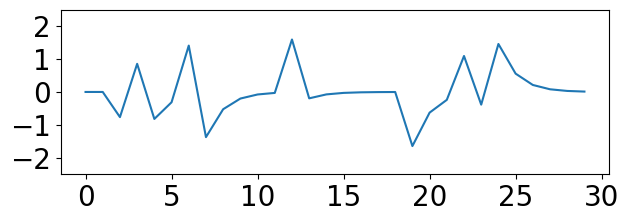

In [32]:
plt.plot(DoE[0])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoE-band0.pdf', transparent=True)
plt.savefig('figs/blocks-DoE-band0.eps', transparent=True)

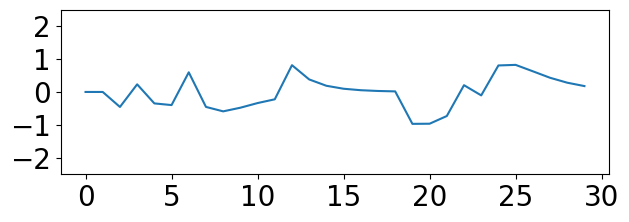

In [33]:
plt.plot(DoE[1])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoE-band1.pdf', transparent=True)
plt.savefig('figs/blocks-DoE-band1.eps', transparent=True)

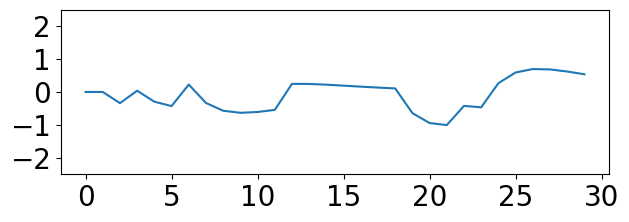

In [34]:
plt.plot(DoE[2])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoE-band2.pdf', transparent=True)
plt.savefig('figs/blocks-DoE-band2.eps', transparent=True)

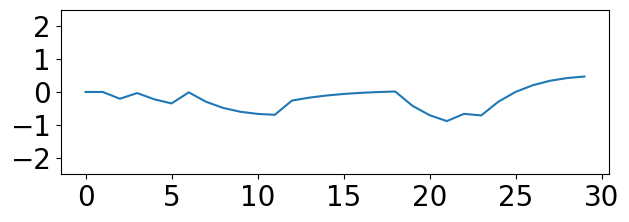

In [35]:
plt.plot(DoE[3])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoE-band3.pdf', transparent=True)
plt.savefig('figs/blocks-DoE-band3.eps', transparent=True)

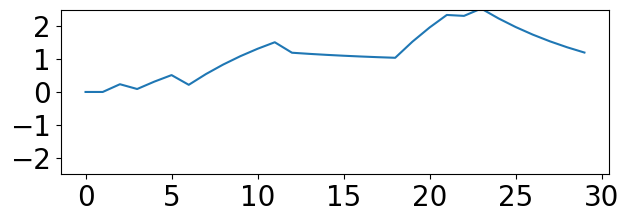

In [36]:
plt.plot(lastlevel)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 2.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoE-last.pdf', transparent=True)
plt.savefig('figs/blocks-DoE-last.eps', transparent=True)

In [37]:
reconstr_DoE = bandpass.reconstr_from_bandpass_DoG(DoE, lastlevel)
reconstr_DoE.shape

(30,)

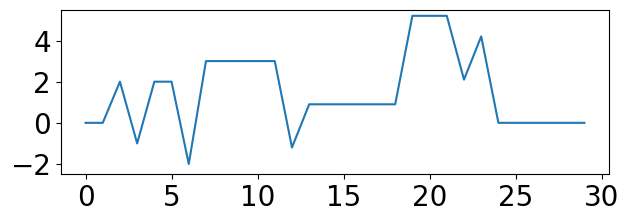

In [38]:
plt.plot(reconstr_DoE)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.gca().set_ylim([-2.5, 5.5])
plt.gca().axes.set_box_aspect(0.3)
plt.tight_layout() 
plt.savefig('figs/blocks-DoE-reconstr.pdf', transparent=True)
plt.savefig('figs/blocks-DoE-reconstr.eps', transparent=True)

In [39]:
blocks - reconstr_DoE

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -1.11022302e-16,
       -4.44089210e-16,  0.00000000e+00, -2.22044605e-16,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.11022302e-16, -1.11022302e-16,  0.00000000e+00,
        1.11022302e-16,  0.00000000e+00])

In [40]:
norm(blocks - reconstr_DoE)/norm(blocks)

np.float64(4.1535723213852466e-17)

In [41]:
norm(blocks)

np.float64(13.09465539829132)